In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from statsmodels.tsa.stattools import acf

def Optimal_Tau(Data, max_lag=50):
    acf_values = acf(Data, nlags=max_lag, fft=True)
    for lag in range(1, len(acf_values)):
        if acf_values[lag] * acf_values[lag-1] < 0:
            return lag
    return 1

def Probability(Data, M = 5):
    tau = Optimal_Tau(Data)
    z = np.zeros((len(Data) - (M - 1) * tau, M))

    for i in range(len(Data) - (M - 1) * tau):
        for j in range(M):
            z[i][j] = Data[i + j * tau] 

    e = np.argsort(z, axis = 1)
        
    pattern_count = {}
    for pattern in e:
        key = tuple(pattern)
        pattern_count[key] = pattern_count.get(key, 0) + 1
            
    total = sum(pattern_count.values())
    P = np.array([count / total for count in pattern_count.values()])
    return P

def Probability_U(P):
    return np.full(shape=len(P), fill_value=1/len(P))

def Probability_Const(P):
    p = np.zeros(len(P))
    p[0] = 1
    return p

def Entropy(P):
    P = P[P > 0]
    return -np.sum(P * np.log2(P))

def J(P1, P2):
    P3 = np.add(P1, P2) / 2
    return Entropy(P3) - 0.5 * (Entropy(P1) + Entropy(P2))

In [2]:
from scipy.io import arff
import pandas as pd

raw_data, meta = arff.loadarff('AbnormalHeartbeat_TEST.arff')
df = pd.DataFrame(raw_data)
feature_columns = [col for col in df.columns if col != 'target']
X = df[feature_columns].values.astype(np.float32)
Y = df['target'].values

Количество рядов: 205
Длина ряда: 18530


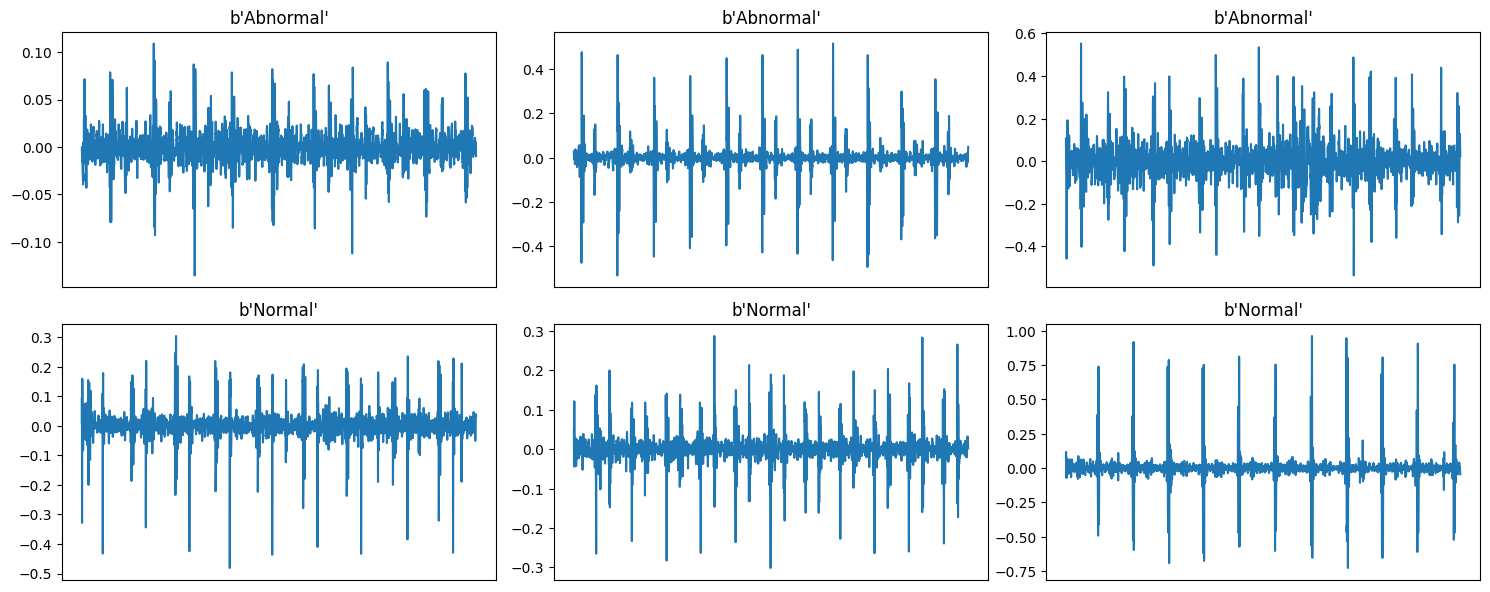

In [3]:
print("Количество рядов:", X.shape[0])
print("Длина ряда:", X.shape[1])

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i in range(3):
    axes[0, i].plot(X[i])
    axes[0, i].set_title(Y[i])
    axes[0, i].set_xticks([])
for j in range(3):
    idx = -3 + j
    axes[1, j].plot(X[idx])
    axes[1, j].set_title(Y[idx])
    axes[1, j].set_xticks([])
plt.tight_layout()
plt.show()

In [15]:
import ordpy

def entropy_complexity(Data, M=6):
    H, C = ordpy.complexity_entropy(Data, dx=M)
    return H, C

In [8]:
print('MyEntropy │  OrdPayEntropy │  MyComplexity │  OrdPayComplexity')
print('----------┼----------------┼---------------┼-------------------')
idx = [0, 1, 2, 4, 5] + [len(X)-5, len(X)-4, len(X)-3, len(X)-2, len(X)-1]
for i in idx:
    data = X[i].copy()
    prob = Probability(data)
    prob_u = Probability_U(prob)
    prob_const = Probability_Const(prob)
    entropy1 = Entropy(prob) / Entropy(prob_u)
    complexity1 = entropy1 * (J(prob, prob_u) / J(prob_u, prob_const))
    entropy2, complexity2 =  entropy_complexity(data)
    print(f'{entropy1:8.5f}  │ {entropy2:14.5f} │ {complexity1:13.5f} │ {complexity2:14.5f}')

MyEntropy │  OrdPayEntropy │  MyComplexity │  OrdPayComplexity
----------┼----------------┼---------------┼-------------------
 0.93904  │        0.63223 │       0.09988 │        0.27243
 0.94396  │        0.63554 │       0.09380 │        0.26753
 0.97625  │        0.40469 │       0.04232 │        0.27512
 0.93746  │        0.64808 │       0.09865 │        0.26734
 0.89999  │        0.70467 │       0.15624 │        0.25479
 0.93000  │        0.49079 │       0.11703 │        0.28799
 0.96210  │        0.44480 │       0.06262 │        0.27726
 0.91456  │        0.48788 │       0.14291 │        0.27518
 0.92660  │        0.46273 │       0.11828 │        0.28408
 0.95264  │        0.58586 │       0.07986 │        0.27276


In [51]:
Normal_Entropy = []
Normal_Complexity = []
Abnormal_Entropy = []
Abnormal_Complexity = []

for i in tqdm(range(len(X))):
    data = X[i].copy()
    prob = Probability(data)
    prob_u = Probability_U(prob)
    prob_const = Probability_Const(prob)
    entropy = Entropy(prob) / Entropy(prob_u)
    complexity = entropy * (J(prob, prob_u) / J(prob_u, prob_const))
    if (Y[i] == b'Normal'):
        Normal_Entropy.append(entropy)
        Normal_Complexity.append(complexity)
    else:
        Abnormal_Entropy.append(entropy)
        Abnormal_Complexity.append(complexity)


100%|██████████| 205/205 [00:07<00:00, 27.69it/s]


In [16]:
Normal_Entropy = []
Normal_Complexity = []
Abnormal_Entropy = []
Abnormal_Complexity = []

for i in tqdm(range(len(X))):
    entropy, complexity = entropy_complexity(X[i])
    if (Y[i] == b'Normal'):
        Normal_Entropy.append(entropy)
        Normal_Complexity.append(complexity)
    else:
        Abnormal_Entropy.append(entropy)
        Abnormal_Complexity.append(complexity)

100%|██████████| 205/205 [00:09<00:00, 22.12it/s]


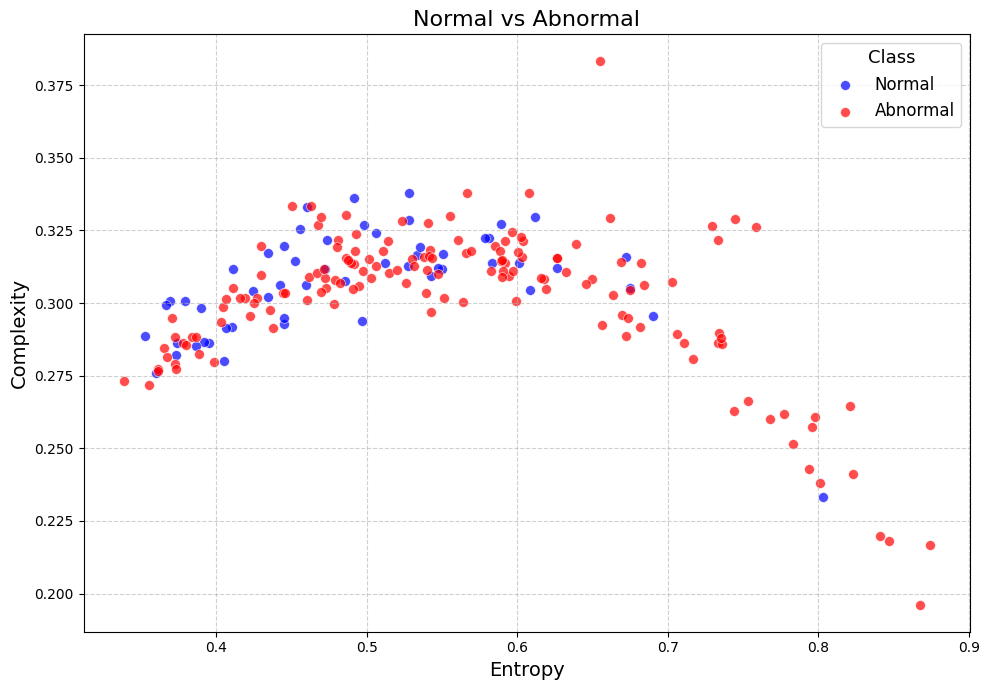

In [17]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

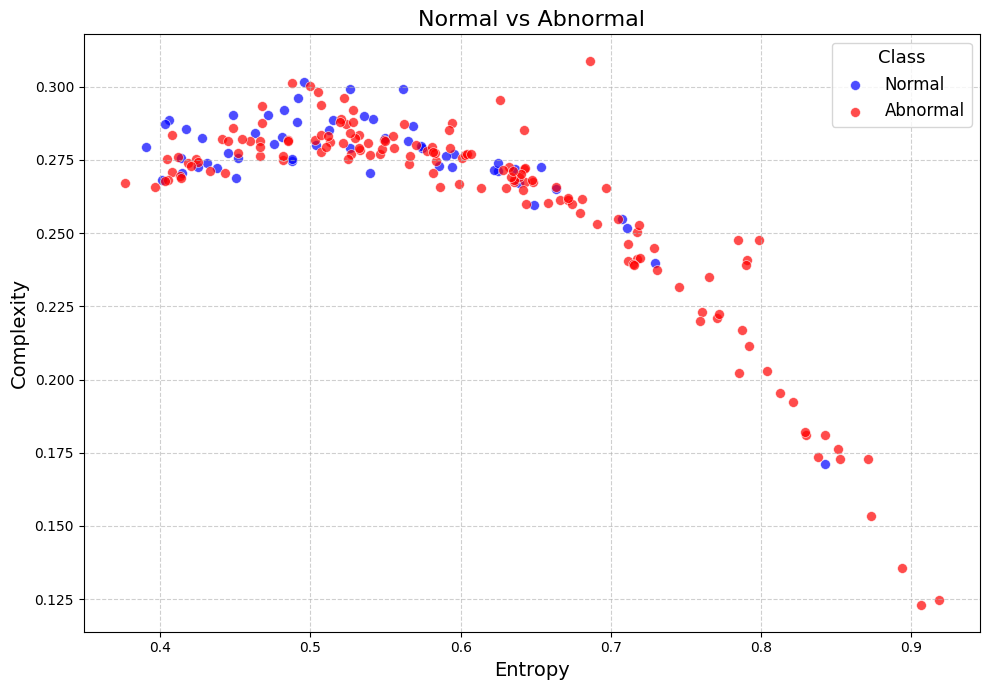

In [11]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

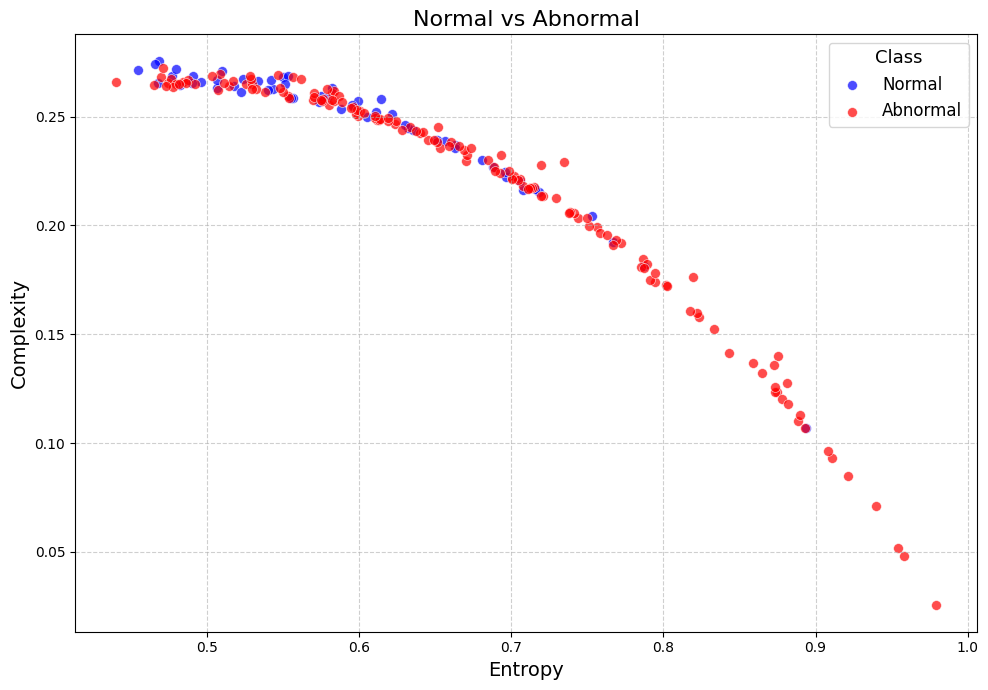

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

In [18]:
def hurst_exponent(Data):
    mean_data = np.mean(Data)
    deviations = Data - mean_data
    sum_dev = np.cumsum(deviations)
    T = np.arange(2, len(Data)) 
    R_S = []
    
    for t in T:
        R = np.max(sum_dev[:t]) - np.min(sum_dev[:t])
        S = np.std(Data[:t])
        
        if S > 0:
            R_S.append(R / S)
        else:
            R_S.append(np.nan)
    
    log_T = np.log(T)
    log_R_S = np.log(R_S)
    
    mask = ~np.isnan(log_R_S)
    log_T = log_T[mask]
    log_R_S = log_R_S[mask]

    H, _ = np.polyfit(log_T, log_R_S, 1)
    
    return H

Графики первых попыток Entopy-complexity

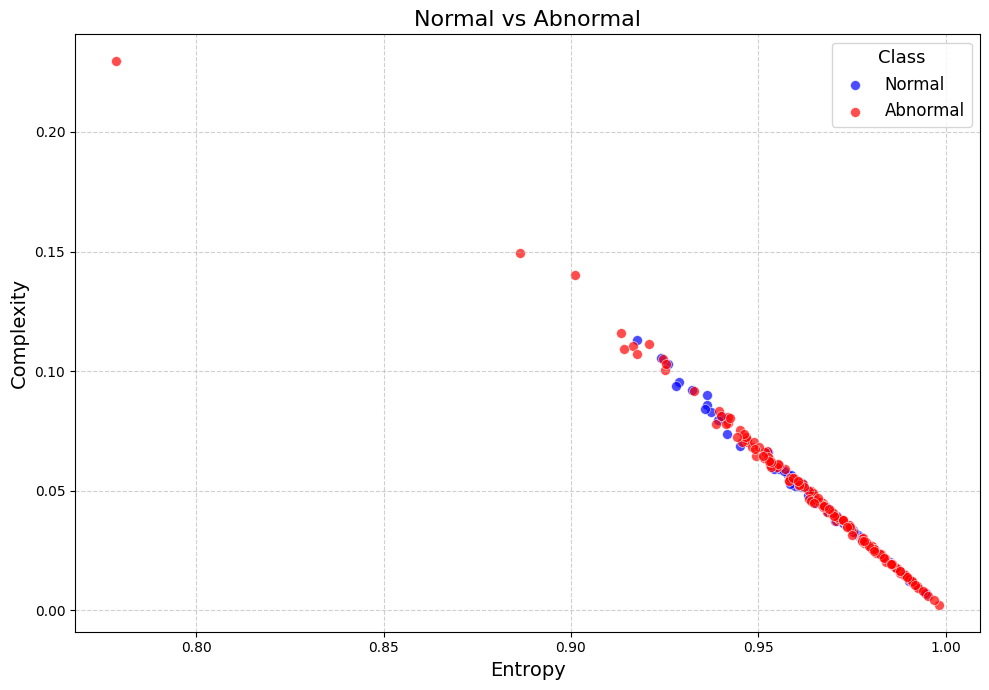

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

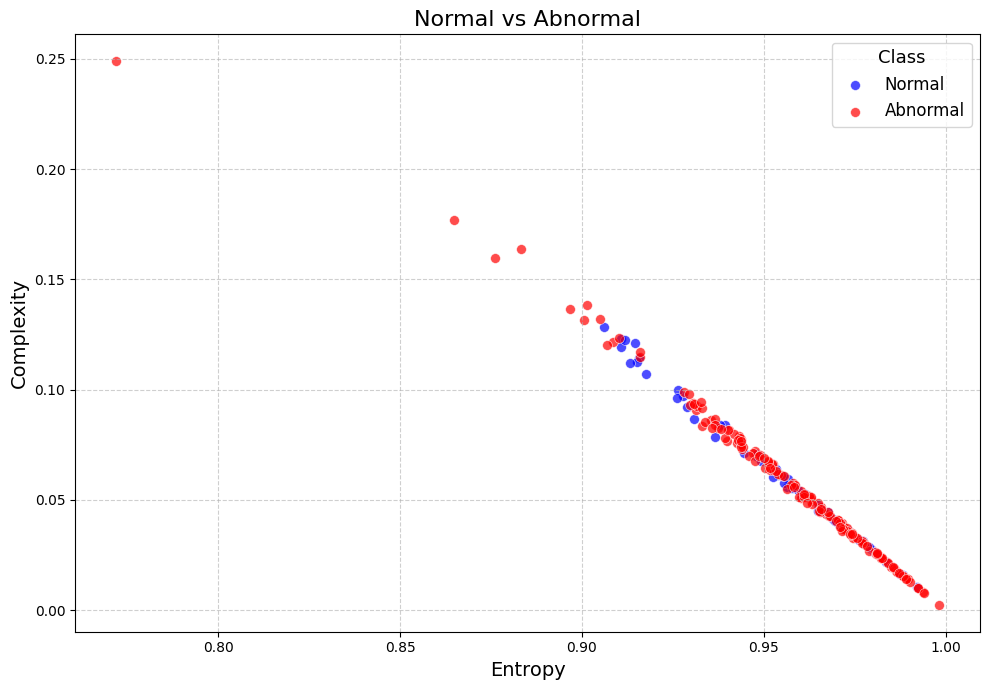

In [37]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

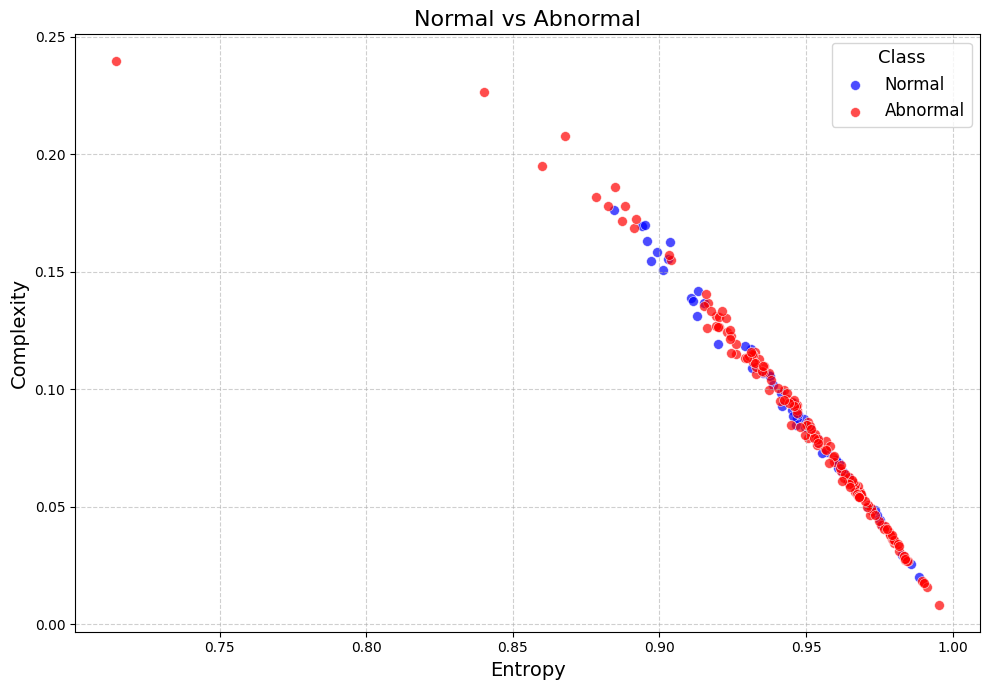

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

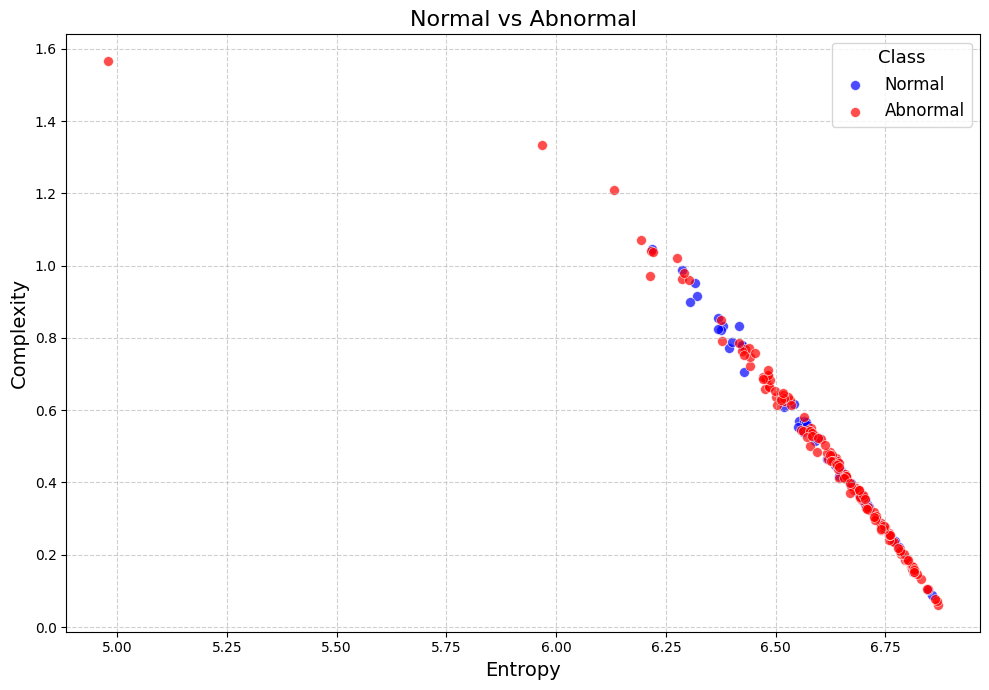

In [26]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

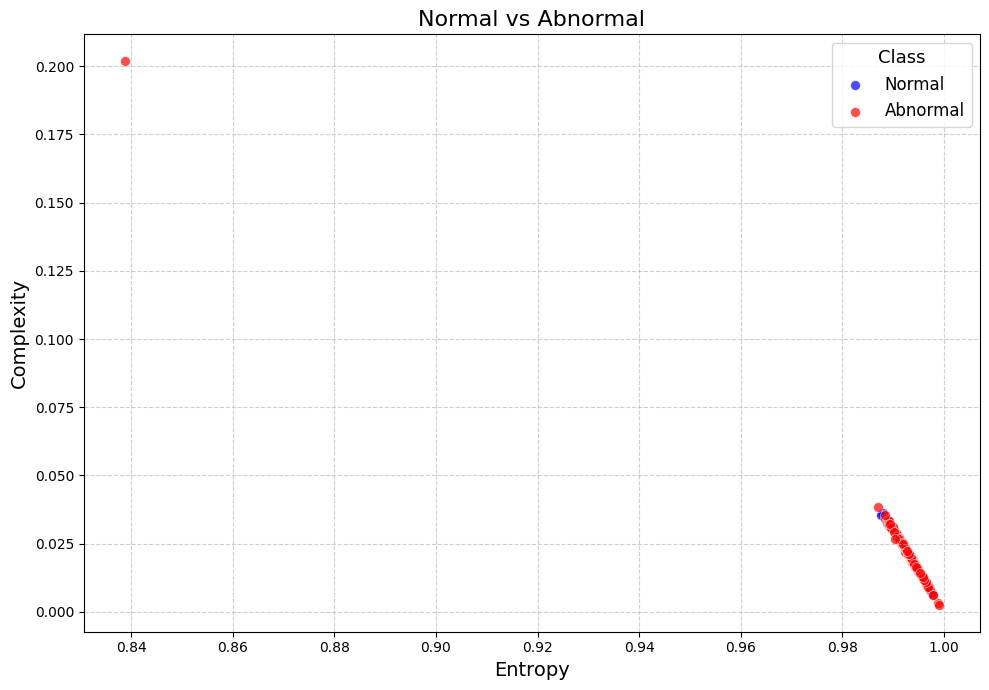

In [35]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

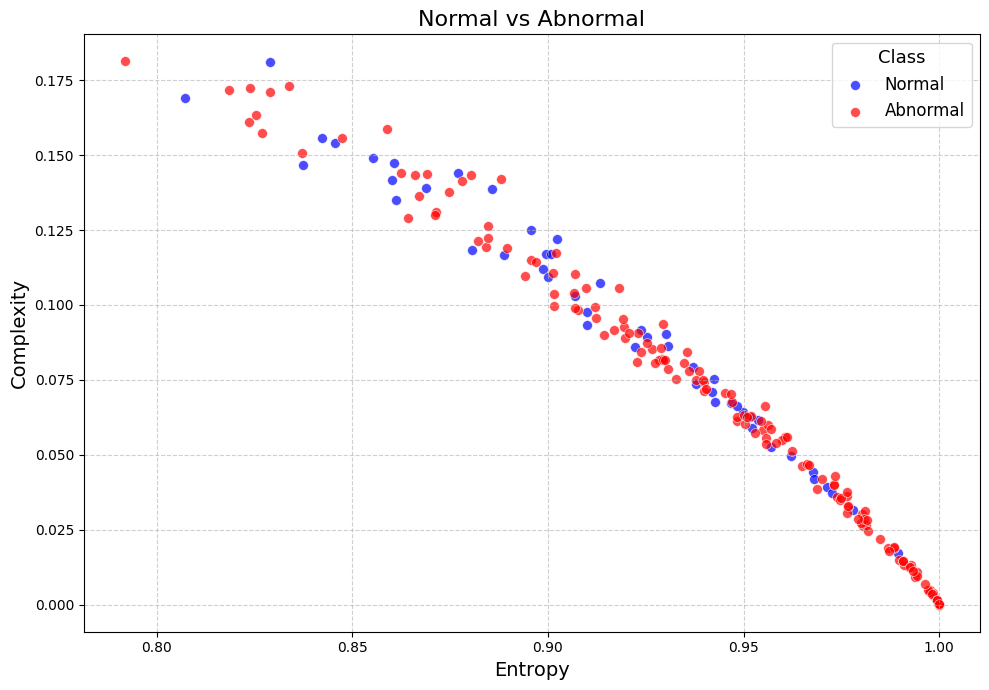

In [52]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

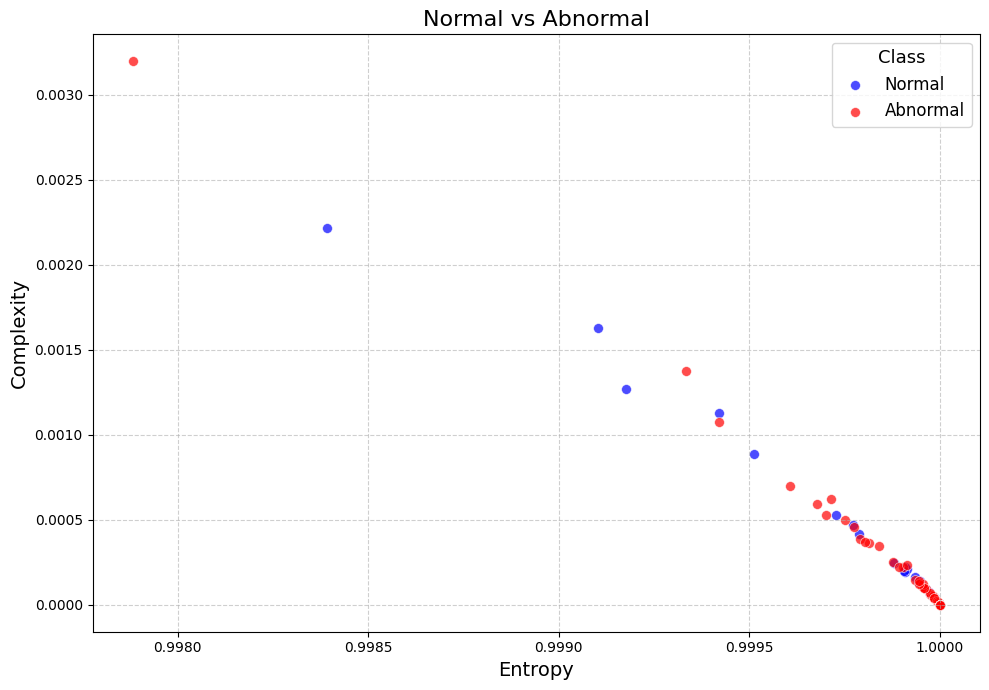

In [56]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

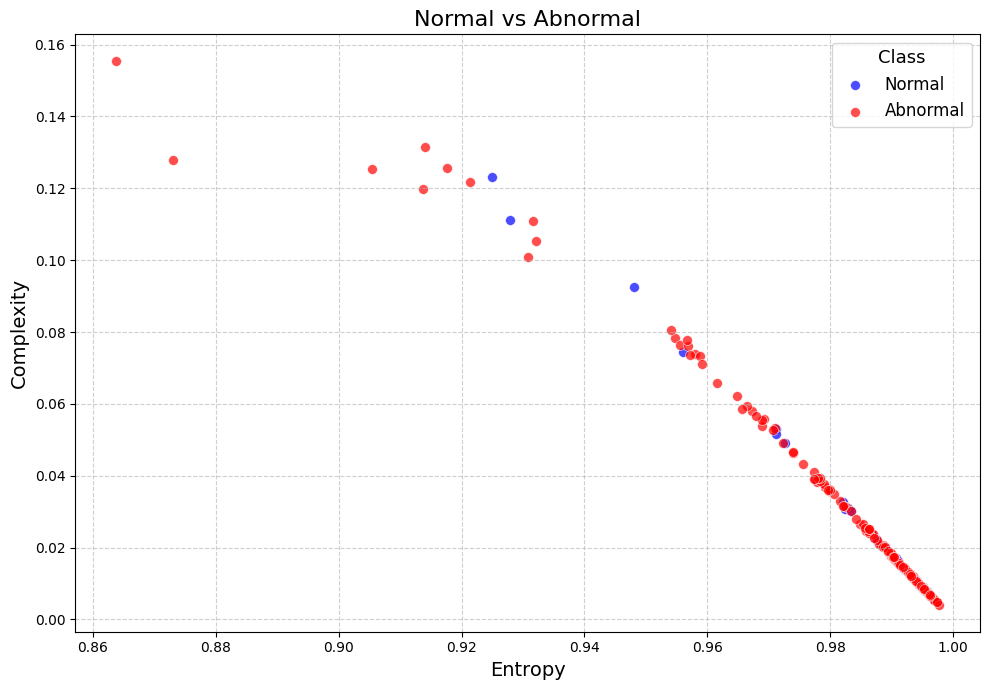

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

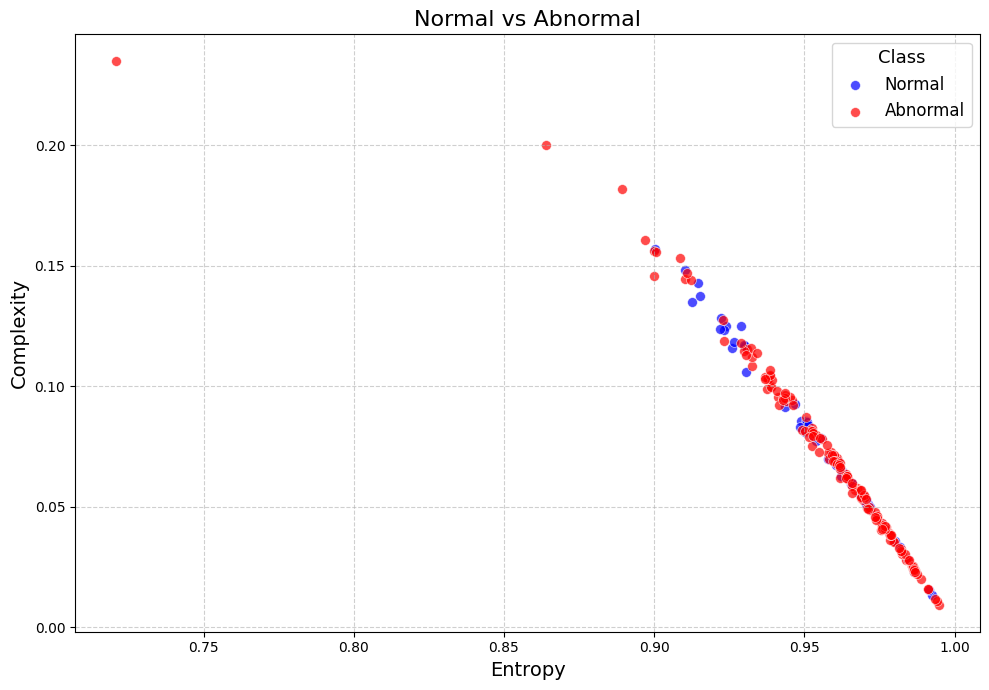

In [52]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()